# From XML to Entities: Corpus Exploration and NER

This notebook explores the textual characteristics of *Repertorium Germanicum I* and applies several different Name Entity Recognition (NER) tool to the complete corpus.




## Import Libraries and Sanity check


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np


In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/digital_philology_rg1")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"


In [ ]:
segments_path = DATA_DIR / "rg1_segments.csv"
abbreviations_path = DATA_DIR / "rg1_abbreviations.csv"

segments = pd.read_csv(segments_path)
abbreviations = pd.read_csv(abbreviations_path)

print("Segments:", segments.shape)
print("Abbreviations:", abbreviations.shape)



Segments: (9434, 14)
Abbreviations: (30118, 7)


## 1. Basic corpus exploration

The corpus consists primarily of concise Latin regesta: short summaries of historical records rather than continuous prose. Also, the texts contain a lot of abbreviations, dates, archival references, personal names, place, and German-speaking regions.


These characteristics make it difficult for named entity recognition tools. Most pretrained NER models were developed using modern, standardized language.

Before going into NER, this section therefore conducts some corpus exploration to know the linguistic features of the corpus.




In [ ]:
TEXT_COLUMN = "analysis_text"

corpus_summary = pd.DataFrame({
    "Measure": [
        "Number of lemmas",
        "Number of text segments",
        "Number of words",
        "Number of characters",
        "Number of abbreviation occurrences",
        "Number of date occurrences",
        "Number of source references",
        "Segments containing abbreviations",
        "Segments containing dates"
    ],
    "Value": [
        segments["lemma_id"].nunique(),
        len(segments),
        segments["word_count"].sum(),
        segments["character_count"].sum(),
        segments["abbreviation_count"].sum(),
        segments["date_count"].sum(),
        segments["source_count"].sum(),
        (segments["abbreviation_count"] > 0).sum(),
        (segments["date_count"] > 0).sum()
    ]
})

display(corpus_summary)

,Measure,Value
0,Number of lemmas,3845
1,Number of text segments,9434
2,Number of words,76087
3,Number of characters,462135
4,Number of abbreviation occurrences,30118
5,Number of date occurrences,1103
6,Number of source references,5260
7,Segments containing abbreviations,8288
8,Segments containing dates,1103


In [ ]:
section_summary = (
    segments.groupby("section")
    .agg(
        segments=("segment_id", "count"),
        total_words=("word_count", "sum"),
        abbreviation_occurrences=("abbreviation_count", "sum"),
        date_occurrences=("date_count", "sum")
    )
    .reset_index()
)

display(section_summary)

,section,segments,total_words,abbreviation_occurrences,date_occurrences
0,head,3845,24345,8592,0
1,sublemma,5589,51742,21526,1103


,word_count
count,9434.000000
mean,8.065190
std,6.206207
min,1.000000
25%,5.000000
50%,7.000000
75%,10.000000
90%,14.000000
95%,16.000000
99%,27.000000


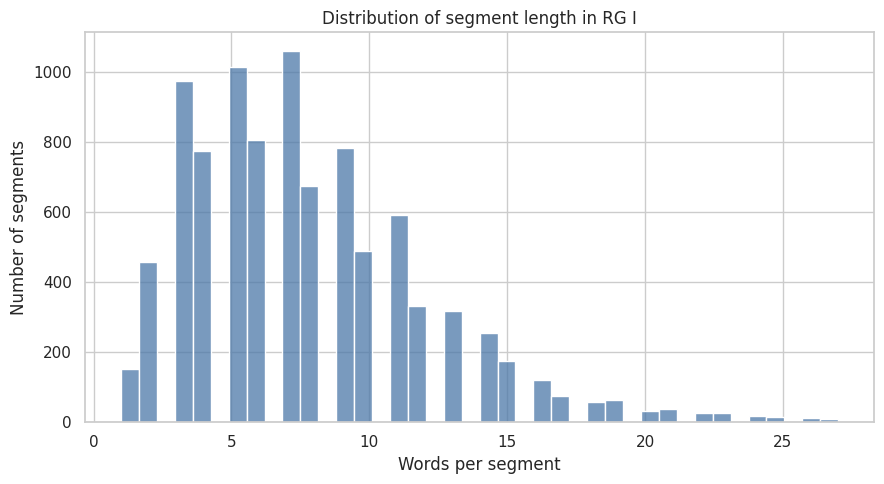

99% of segments contain no more than 27 words.
Longest segment: 208 words.


In [ ]:
length_summary = segments["word_count"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(length_summary.to_frame("word_count"))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

upper_limit = segments["word_count"].quantile(0.99)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=segments[segments["word_count"] <= upper_limit],
    x="word_count",
    bins=40,
    color="#4C78A8"
)

plt.title("Distribution of segment length in RG I")
plt.xlabel("Words per segment")
plt.ylabel("Number of segments")
plt.tight_layout()
plt.show()

print(f"99% of segments contain no more than {upper_limit:.0f} words.")
print(f"Longest segment: {segments['word_count'].max()} words.")

In [ ]:
longest_segment = segments.loc[segments["word_count"].idxmax()]

print("Lemma ID:", longest_segment["lemma_id"])
print("Segment ID:", longest_segment["segment_id"])
print("Section:", longest_segment["section"])
print("Word count:", longest_segment["word_count"])
print("Abbreviation count:", longest_segment["abbreviation_count"])
print("\nText:\n")
print(longest_segment["analysis_text"])

Lemma ID: 10102151
Segment ID: 10102151-13
Section: sublemma
Word count: 208
Abbreviation count: 37

Text:

cumque propter diversos processus a quodam Syfrido can. et decan. eccl. s. Jacobi Bamberg. ut executore [assignante] cuidam Conrado dicto Schilher ecclesiam par. in Tronstat Herbip. dioc., quam tunc idem Johannes de Leone pacifice possidebat, a dicte Bartholomeo impetranti et deputato, ac [propter] notoriam assistentiam Friderici dicti Heyden can. preb. eccl. Bamberg. notorie dicto Barth. et anticardinali Ravennaten. adherentis nunc in Rom. curia moram trahentis et pluribus vicibus falsas indulgentias prefati anticard. post ipsius sermones populo publicandos intimantis prefatus Johannes dicta sua eccl. sit spoliatus, supplic. prefatas personas rebelles beneficiis et oblagiis motu proprio privare et Eberhardo dicte Goltstein rectori par. eccl. in Karbach Herbip. dioc. de can. et preb. ac oblagiis Nicolai, ac Michaeli de Leone rectori par. eccl. in Ballenburg dicte dioc. de can. et

,Feature,Segments,Percentage
0,Contains abbreviation,8288,87.9
1,Contains date,1103,11.7
2,Contains source reference,4910,52.0
3,Contains KA tag,651,6.9
4,Contains KZ tag,652,6.9


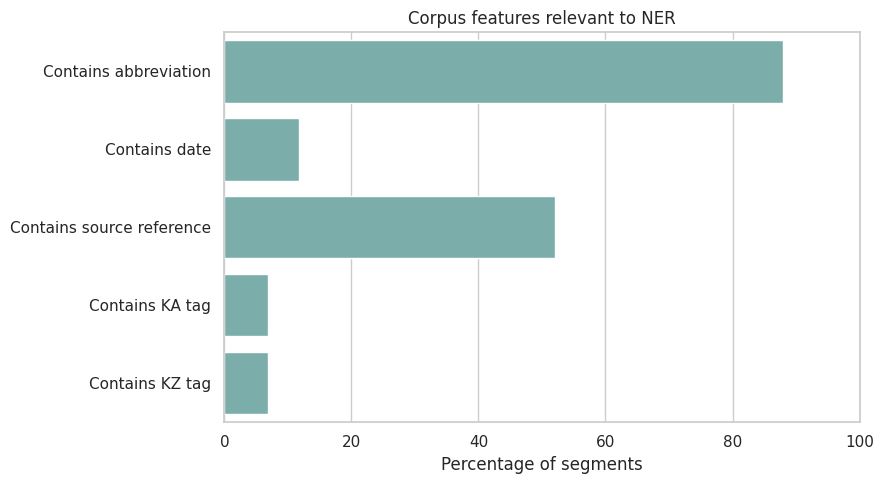

In [ ]:
feature_coverage = pd.DataFrame({
    "Feature": [
        "Contains abbreviation",
        "Contains date",
        "Contains source reference",
        "Contains KA tag",
        "Contains KZ tag"
    ],
    "Segments": [
        (segments["abbreviation_count"] > 0).sum(),
        (segments["date_count"] > 0).sum(),
        (segments["source_count"] > 0).sum(),
        (segments["ka_count"] > 0).sum(),
        (segments["kz_count"] > 0).sum()
    ]
})

feature_coverage["Percentage"] = (
    feature_coverage["Segments"] / len(segments) * 100
).round(1)

display(feature_coverage)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_coverage,
    x="Percentage",
    y="Feature",
    color="#72B7B2"
)

plt.title("Corpus features relevant to NER")
plt.xlabel("Percentage of segments")
plt.ylabel("")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


## 2. Preparing the NER input

The `analysis_text` field is used as the input for NER. It retains the textual
content, abbreviations, dates, and historical name forms, while excluding structured
source references extracted from the XML.

Only redundant whitespace is normalized. Abbreviations, punctuation, spelling, and
capitalization are preserved because they are relevant characteristics of the
historical corpus.

In [ ]:
ner_input = segments[
    [
        "lemma_id",
        "segment_id",
        "section",
        "segment_order",
        "analysis_text",
        "word_count",
        "abbreviation_count",
        "abbreviation_density",
        "date_count"
    ]
].copy()

ner_input["ner_text"] = (
    ner_input["analysis_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("NER input segments:", len(ner_input))
print("Empty texts:", ner_input["ner_text"].eq("").sum())
print("Duplicate segment IDs:", ner_input["segment_id"].duplicated().sum())

display(ner_input.head())

ner_input_path = OUTPUT_DIR / "rg1_ner_input.csv"

ner_input.to_csv(
    ner_input_path,
    index=False,
    encoding="utf-8"
)

print("Saved to:", ner_input_path)

NER input segments: 9434
Empty texts: 0
Duplicate segment IDs: 0


,lemma_id,segment_id,section,segment_order,analysis_text,word_count,abbreviation_count,abbreviation_density,date_count,ner_text
0,10100001,10100001-0,head,0,Abardus Alamannus,2,0,0.000000,0,Abardus Alamannus
1,10100001,10100001-1,sublemma,1,qui portavit litteras d. pape ex parte marchio...,17,2,0.117647,0,qui portavit litteras d. pape ex parte marchio...
2,10100002,10100002-0,head,0,Achatius Erhardi Asini de Monteferri cler. Sal...,8,2,0.250000,0,Achatius Erhardi Asini de Monteferri cler. Sal...
3,10100002,10100002-1,sublemma,1,de benef. ad coll. abb. etc. mon. s. Tru[d]per...,23,12,0.521739,0,de benef. ad coll. abb. etc. mon. s. Tru[d]per...
4,10100003,10100003-0,head,0,Achatius Nicolai Wenke de Nisa cler. Wratislav...,8,3,0.375000,0,Achatius Nicolai Wenke de Nisa cler. Wratislav...


Saved to: /content/drive/MyDrive/digital_philology_rg1/outputs/rg1_ner_input.csv


## 3. NER Model 1: LatinCy

The first NER model is `la_core_web_lg`, a Latin-specific spaCy pipeline developed
by LatinCy. Its NER component identifies three entity categories:

- `PERSON`: named individuals;
- `LOC`: geographical locations;
- `NORP`: national, religious, or political groups.

LatinCy provides an appropriate Latin-specific baseline. However, it was not trained
specifically on the abbreviated papal regesta of RG I. Its published evaluation
scores therefore describe performance on its own annotated data, not accuracy on
the present corpus.

Model: [LatinCy `la_core_web_lg`](https://huggingface.co/latincy/la_core_web_lg)

In [ ]:
%pip install -q "https://huggingface.co/latincy/la_core_web_lg/resolve/main/la_core_web_lg-3.9.6-py3-none-any.whl"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.9/296.9 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 490.8/490.8 kB 47.0 MB/s eta 0:00:00


In [ ]:
import spacy
import la_core_web_lg
from tqdm.auto import tqdm
latincy_nlp = la_core_web_lg.load()
latincy_rows = []

records = ner_input.to_dict("records")
doc_stream = latincy_nlp.pipe(
    ner_input["ner_text"].tolist(),
    batch_size=64
)

for record, doc in tqdm(
    zip(records, doc_stream),
    total=len(records),
    desc="Running LatinCy"
):
    for entity in doc.ents:
        latincy_rows.append({
            "lemma_id": record["lemma_id"],
            "segment_id": record["segment_id"],
            "section": record["section"],
            "model": "latincy_la_core_web_lg",
            "entity": entity.text,
            "label": entity.label_,
            "start": entity.start_char,
            "end": entity.end_char
        })

latincy_results = pd.DataFrame(
    latincy_rows,
    columns=[
        "lemma_id",
        "segment_id",
        "section",
        "model",
        "entity",
        "label",
        "start",
        "end"
    ]
)

print("Segments processed:", len(ner_input))
print("Entities extracted:", len(latincy_results))

Running LatinCy:   0%|          | 0/9434 [00:00<?, ?it/s]

Segments processed: 9434
Entities extracted: 17004


In [ ]:
latincy_output_path = OUTPUT_DIR / "ner_latincy.csv"

latincy_results.to_csv(
    latincy_output_path,
    index=False,
    encoding="utf-8"
)

print("Saved to:", latincy_output_path)

Saved to: /content/drive/MyDrive/digital_philology_rg1/outputs/ner_latincy.csv


In [ ]:
latincy_summary = pd.DataFrame({
    "Measure": [
        "Segments processed",
        "Segments with at least one entity",
        "Entity mentions",
        "Unique entity strings"
    ],
    "Value": [
        len(ner_input),
        latincy_results["segment_id"].nunique(),
        len(latincy_results),
        latincy_results["entity"].nunique()
    ]
})

display(latincy_summary)

display(
    latincy_results["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="entities")
)

,Measure,Value
0,Segments processed,9434
1,Segments with at least one entity,7811
2,Entity mentions,17004
3,Unique entity strings,4337


,label,entities
0,PERSON,15819
1,LOC,1075
2,NORP,110


## 4. Model 2: Multilingual Medieval RoBERTa

The second model is `magistermilitum/roberta-multilingual-medieval-ner`, an XLM-RoBERTa-large model fine-tuned on approximately 8,000 annotated medieval charters in Medieval Latin, Old French, and Old Spanish, dating from the 11th to the 15th centuries.

The model identifies persons (`PERS`) and locations (`LOC`).For comparison, `PERS` is normalized to `PERSON`. Only the common categories
`PERSON` and `LOC` will be used in direct cross-model comparisons.

Model: [Multilingual Medieval RoBERTa](https://huggingface.co/magistermilitum/roberta-multilingual-medieval-ner)



In [ ]:
%pip install -q transformers accelerate sentencepiece

In [ ]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    pipeline
)

MODEL_ID = "magistermilitum/roberta-multilingual-medieval-ner"

medieval_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    use_fast=True
)

# The model documentation recommends shorter input units.
# Longer segments will be processed with overlapping chunks.
medieval_tokenizer.model_max_length = 256

medieval_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_ID,
    dtype=torch.float16
)

medieval_ner = pipeline(
    task="token-classification",
    model=medieval_model,
    tokenizer=medieval_tokenizer,
    aggregation_strategy="first",
    stride=32,
    device=0
)

print("Model loaded:", MODEL_ID)
print("Maximum tokens per chunk:", medieval_tokenizer.model_max_length)
print("Labels:", medieval_model.config.id2label)

Invalid model-index. Not loading eval results into CardData.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Invalid model-index. Not loading eval results into CardData.
[transformers] XLMRobertaForTokenClassification LOAD REPORT from: magistermilitum/roberta-multilingual-medieval-ner
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: magistermilitum/roberta-multilingual-medieval-ner
Maximum tokens per chunk: 256
Labels: {0: 'O', 1: 'B-LOC', 2: 'B-PERS', 3: 'I-PERS', 4: 'L-PERS', 5: 'I-LOC'}


In [ ]:
from tqdm.auto import tqdm

medieval_rows = []

CHUNK_SIZE = 250
PIPELINE_BATCH_SIZE = 8

checkpoint_path = OUTPUT_DIR / "ner_medieval_roberta_checkpoint.csv"

for batch_start in tqdm(
    range(0, len(ner_input), CHUNK_SIZE),
    desc="Running Medieval RoBERTa"
):
    batch_end = min(batch_start + CHUNK_SIZE, len(ner_input))
    batch_df = ner_input.iloc[batch_start:batch_end]

    batch_predictions = medieval_ner(
        batch_df["ner_text"].tolist(),
        batch_size=PIPELINE_BATCH_SIZE
    )

    for record, predictions in zip(
        batch_df.to_dict("records"),
        batch_predictions
    ):
        text = record["ner_text"]

        for prediction in predictions:
            raw_label = prediction["entity_group"]

            if "PERS" in raw_label:
                normalized_label = "PERSON"
            elif "LOC" in raw_label:
                normalized_label = "LOC"
            else:
                normalized_label = raw_label

            start = int(prediction["start"])
            end = int(prediction["end"])

            medieval_rows.append({
                "lemma_id": record["lemma_id"],
                "segment_id": record["segment_id"],
                "section": record["section"],
                "model": "roberta_multilingual_medieval_ner",
                "entity": text[start:end],
                "original_label": raw_label,
                "label": normalized_label,
                "start": start,
                "end": end,
                "score": float(prediction["score"])
            })

    # Save a temporary checkpoint after every 1,000 segments
    if batch_end % 1000 == 0 or batch_end == len(ner_input):
        pd.DataFrame(medieval_rows).to_csv(
            checkpoint_path,
            index=False,
            encoding="utf-8"
        )

        print(
            f"Checkpoint: {batch_end}/{len(ner_input)} segments, "
            f"{len(medieval_rows)} entity predictions"
        )

Running Medieval RoBERTa:   0%|          | 0/38 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Checkpoint: 1000/9434 segments, 1724 entity predictions


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Checkpoint: 2000/9434 segments, 3489 entity predictions


...

Checkpoint: 8000/9434 segments, 13725 entity predictions


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Checkpoint: 9000/9434 segments, 15433 entity predictions


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Checkpoint: 9434/9434 segments, 16172 entity predictions


In [ ]:
medieval_results = pd.DataFrame(medieval_rows)

before_deduplication = len(medieval_results)

medieval_results = (
    medieval_results
    .sort_values("score", ascending=False)
    .drop_duplicates(
        subset=["segment_id", "label", "start", "end", "entity"],
        keep="first"
    )
    .sort_values(["segment_id", "start", "end"])
    .reset_index(drop=True)
)

print("Before:", before_deduplication)
print("After:", len(medieval_results))


medieval_output_path = OUTPUT_DIR / "ner_medieval_roberta.csv"

medieval_results.to_csv(
    medieval_output_path,
    index=False,
    encoding="utf-8"
)

print("Saved to:", medieval_output_path)

Before: 16172
After: 16172
Saved to: /content/drive/MyDrive/digital_philology_rg1/outputs/ner_medieval_roberta.csv


In [ ]:
print("Segments processed:", len(ner_input))
print(
    "Segments with entities:",
    medieval_results["segment_id"].nunique()
)
print("Entity mentions:", len(medieval_results))
print(
    "Unique entity strings:",
    medieval_results["entity"].nunique()
)

display(
    medieval_results["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="entities")
)

Segments processed: 9434
Segments with entities: 8015
Entity mentions: 16172
Unique entity strings: 7603


,label,entities
0,PERSON,13891
1,LOC,2281


## 5. Model 3: General Multilingual XLM-RoBERTa

The third model is `Davlan/xlm-roberta-base-ner-hrl`, a general multilingual NER
model fine-tuned on ten high-resource modern languages. Its NER fine-tuning data
does not include Latin and consists primarily of modern news-oriented corpora.

The model recognizes persons (`PER`), locations (`LOC`), and organizations (`ORG`).
It is included as an out-of-domain multilingual baseline to investigate whether
multilingual transfer alone can produce useful predictions for the abbreviated
historical Latin of RG I.

For direct cross-model comparison, `PER` is normalized to `PERSON`, and only the
shared `PERSON` and `LOC` categories are compared. `ORG` is retained as an
additional model-specific output.

Model: [Davlan XLM-RoBERTa NER](https://huggingface.co/Davlan/xlm-roberta-base-ner-hrl)

In [ ]:
import gc
import torch

del medieval_ner
del medieval_model
del medieval_tokenizer

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU memory allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

GPU memory allocated: 1.05 GB


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    pipeline
)

XLMR_MODEL_ID = "Davlan/xlm-roberta-base-ner-hrl"

xlmr_tokenizer = AutoTokenizer.from_pretrained(
    XLMR_MODEL_ID,
    use_fast=True
)

xlmr_tokenizer.model_max_length = 512

xlmr_model = AutoModelForTokenClassification.from_pretrained(
    XLMR_MODEL_ID,
    dtype=torch.float16
)

xlmr_ner = pipeline(
    task="token-classification",
    model=xlmr_model,
    tokenizer=xlmr_tokenizer,
    aggregation_strategy="first",
    stride=64,
    device=0
)

print("Model loaded:", XLMR_MODEL_ID)
print("Maximum tokens per chunk:", xlmr_tokenizer.model_max_length)
print("Labels:", xlmr_model.config.id2label)

config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded: Davlan/xlm-roberta-base-ner-hrl
Maximum tokens per chunk: 512
Labels: {0: 'O', 1: 'B-DATE', 2: 'I-DATE', 3: 'B-PER', 4: 'I-PER', 5: 'B-ORG', 6: 'I-ORG', 7: 'B-LOC', 8: 'I-LOC'}


In [ ]:
from tqdm.auto import tqdm

xlmr_rows = []

CHUNK_SIZE = 250
PIPELINE_BATCH_SIZE = 8

xlmr_checkpoint_path = OUTPUT_DIR / "ner_xlmr_checkpoint.csv"

for batch_start in tqdm(
    range(0, len(ner_input), CHUNK_SIZE),
    desc="Running multilingual XLM-R"
):
    batch_end = min(batch_start + CHUNK_SIZE, len(ner_input))
    batch_df = ner_input.iloc[batch_start:batch_end]

    batch_predictions = xlmr_ner(
        batch_df["ner_text"].tolist(),
        batch_size=PIPELINE_BATCH_SIZE
    )

    for record, predictions in zip(
        batch_df.to_dict("records"),
        batch_predictions
    ):
        text = record["ner_text"]

        for prediction in predictions:
            raw_label = prediction["entity_group"]

            if "PER" in raw_label:
                normalized_label = "PERSON"
            elif "LOC" in raw_label:
                normalized_label = "LOC"
            elif "ORG" in raw_label:
                normalized_label = "ORG"
            else:
                normalized_label = raw_label

            start = int(prediction["start"])
            end = int(prediction["end"])

            xlmr_rows.append({
                "lemma_id": record["lemma_id"],
                "segment_id": record["segment_id"],
                "section": record["section"],
                "model": "davlan_xlmr_ner_hrl",
                "entity": text[start:end],
                "original_label": raw_label,
                "label": normalized_label,
                "start": start,
                "end": end,
                "score": float(prediction["score"])
            })

    if batch_end % 1000 == 0 or batch_end == len(ner_input):
        pd.DataFrame(xlmr_rows).to_csv(
            xlmr_checkpoint_path,
            index=False,
            encoding="utf-8"
        )

        print(
            f"Checkpoint: {batch_end}/{len(ner_input)} segments, "
            f"{len(xlmr_rows)} entity predictions"
        )

Running multilingual XLM-R:   0%|          | 0/38 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Checkpoint: 1000/9434 segments, 1432 entity predictions


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Checkpoint: 2000/9434 segments, 2861 entity predictions


...

Checkpoint: 8000/9434 segments, 11146 entity predictions


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Checkpoint: 9000/9434 segments, 12460 entity predictions


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Checkpoint: 9434/9434 segments, 13049 entity predictions


In [ ]:
xlmr_output_path = OUTPUT_DIR / "ner_xlmr.csv"

xlmr_results.to_csv(
    xlmr_output_path,
    index=False,
    encoding="utf-8"
)

print("Saved to:", xlmr_output_path)


Saved to: /content/drive/MyDrive/digital_philology_rg1/outputs/ner_xlmr.csv


In [ ]:
xlmr_summary = pd.DataFrame({
    "Measure": [
        "Segments processed",
        "Segments with at least one entity",
        "Entity mentions",
        "Unique entity strings"
    ],
    "Value": [
        len(ner_input),
        xlmr_results["segment_id"].nunique(),
        len(xlmr_results),
        xlmr_results["entity"].nunique()
    ]
})

display(xlmr_summary)

display(
    xlmr_results["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="entities")
)

,Measure,Value
0,Segments processed,9434
1,Segments with at least one entity,7843
2,Entity mentions,13049
3,Unique entity strings,7431


,label,entities
0,PERSON,9421
1,LOC,3103
2,ORG,525
